In [ ]:
# 必要なパッケージの読み込み
library(caret)
library(Metrics)
library(ggplot2)
library(lattice)
library(Rborist)

# 対象ファイル名一覧
file_names <- c(
  "n_base.csv", "n_base_OH.csv", "n_base_FP.csv",
  "n_all.csv", "n_all_OH.csv", "n_all_FP.csv",
  "m_base.csv", "m_base_OH.csv", "m_base_FP.csv",
  "m_all.csv", "m_all_OH.csv", "m_all_FP.csv"
)

# データパスの共通部分
base_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/"

# モデルの出力用日付
today <- format(Sys.Date(), "%Y%m%d")

# 評価結果の格納用データフレームの初期化
result_matrix <- matrix(nrow = 5, ncol = length(file_names))
rownames(result_matrix) <- c("Best_predFixed", "Best_minNode", "R2_PCEmax", "RMSE_PCEmax", "RPD_PCEmax")
colnames(result_matrix) <- file_names

#--- メインループ ---#
for (file in file_names) {
  filepath <- paste0(base_path, file)
  cat("\n=== Processing:", file, "===\n")
  df_all <- read.csv(filepath)
  cat("Final dataset size:", dim(df_all)[1], dim(df_all)[2], "\n")

  target_vars <- c("Jsc", "Voc", "FF", "PCEmax")
  feature_vars <- setdiff(colnames(df_all), target_vars)

  for (target_var in target_vars) {
    cat("\n---\nTraining model for:", target_var, "on", file, "\n")
    df <- df_all[, c(feature_vars, target_var)]
    df <- df[complete.cases(df), ]

    # 自動ハイパーパラメータ探索（Rborist）
    tune_grid <- expand.grid(
      predFixed = seq(2, min(10, ncol(df) - 1), by = 2),
      minNode = c(2, 5, 10, 20)
    )

    ctrl <- trainControl(method = "cv", number = 5, verboseIter = FALSE)

    model <- train(
      formula(paste(target_var, "~ .")),
      data = df,
      method = "Rborist",
      metric = "RMSE",
      trControl = ctrl,
      tuneGrid = tune_grid
    )

    # モデル予測と評価
    pred <- predict(model, df)
    obs <- df[[target_var]]

    R2 <- round(cor(pred, obs)^2, 3)
    RMSE_val <- round(rmse(obs, pred), 3)
    MAE_val <- round(mae(obs, pred), 3)
    RPD_val <- round(sd(obs) / RMSE_val, 3)

    best_params <- model$bestTune
    cat("Best parameters: predFixed =", best_params$predFixed, ", minNode =", best_params$minNode, "\n")
    cat(file, target_var, ": R2 =", R2, ", RMSE =", RMSE_val, ", MAE =", MAE_val, ", RPD =", RPD_val, "\n")

    # 結果保存（PCEmax のみ）
    if (target_var == "PCEmax") {
      result_matrix["Best_predFixed", file] <- best_params$predFixed
      result_matrix["Best_minNode", file] <- best_params$minNode
      result_matrix["R2_PCEmax", file] <- R2
      result_matrix["RMSE_PCEmax", file] <- RMSE_val
      result_matrix["RPD_PCEmax", file] <- RPD_val
    }

    # 軸スケールの自動調整
    get_axis_limit <- function(values) {
      max_val <- max(values, na.rm = TRUE)
      if (max_val <= 1.5) {
        return(ceiling(max_val / 0.1) * 0.1)
      } else if (max_val <= 5) {
        return(ceiling(max_val / 0.5) * 0.5)
      } else if (max_val <= 30) {
        return(ceiling(max_val / 2) * 2)
      } else {
        return(ceiling(max_val / 5) * 5)
      }
    }

    range_max <- get_axis_limit(c(obs, pred))

    # プロット
    p <- ggplot(data.frame(Predicted = pred, Observed = obs), aes(x = Observed, y = Predicted)) +
      geom_point(color = "blue", alpha = 0.7) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
      scale_x_continuous(limits = c(0, range_max)) +
      scale_y_continuous(limits = c(0, range_max)) +
      coord_fixed(ratio = 1) +
      labs(
        title = paste0(target_var, " Prediction (", file, ")"),
        x = "Observed",
        y = "Predicted",
        subtitle = paste0("R² = ", R2, ", RMSE = ", RMSE_val, ", MAE = ", MAE_val, ", RPD = ", RPD_val)
      ) +
      theme_minimal()

    print(p)
  }
}

# 結果の保存
write.csv(result_matrix, paste0("Rborist_summary_", today, ".csv"), row.names = TRUE)
cat("\nSummary saved as Rborist_summary_", today, ".csv\n")


Loading required package: ggplot2

Loading required package: lattice


Attaching package: 'Metrics'


The following objects are masked from 'package:caret':

    precision, recall


Rborist 0.3-11

Type RboristNews() to see new features/changes/bug fixes.




=== Processing: n_base.csv ===
Final dataset size: 358 12 

---
Training model for: Jsc on n_base.csv 


In [3]:
# 必要なパッケージの読み込み
library(caret)
library(Metrics)
library(ggplot2)
library(lattice)

# 対象ファイル名一覧
file_names <- c(
  "n_base.csv", "n_base_OH.csv", "n_base_FP.csv",
  "n_all.csv", "n_all_OH.csv", "n_all_FP.csv",
  "m_base.csv", "m_base_OH.csv", "m_base_FP.csv",
  "m_all.csv", "m_all_OH.csv", "m_all_FP.csv"
)

# データパスの共通部分
base_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/"

# モデルの出力用日付
today <- format(Sys.Date(), "%Y%m%d")

# 評価結果の格納用データフレームの初期化
result_matrix <- matrix(nrow = 5, ncol = length(file_names))
rownames(result_matrix) <- c("Best_C", "R2_PCEmax", "RMSE_PCEmax", "MAE_PCEmax", "RPD_PCEmax")
colnames(result_matrix) <- file_names

#--- メインループ ---#
for (file in file_names) {
  filepath <- paste0(base_path, file)
  cat("\n=== Processing:", file, "===\n")
  df_all <- read.csv(filepath)
  cat("Final dataset size:", dim(df_all)[1], dim(df_all)[2], "\n")

  # 説明変数と目的変数の設定
  target_vars <- c("Jsc", "Voc", "FF", "PCEmax")
  feature_vars <- setdiff(colnames(df_all), target_vars)

  for (target_var in target_vars) {
    cat("\n---\nTraining model for:", target_var, "on", file, "\n")
    df <- df_all[complete.cases(df_all[[target_var]]), c(feature_vars, target_var)]

    # モデルチューニング
    tune_grid <- expand.grid(C = 2^(-5:5))
    ctrl <- trainControl(method = "cv", number = 10)

    model <- train(
      formula(paste(target_var, "~ .")),
      data = df,
      method = "Rborist",
      metric = "RMSE",
      trControl = ctrl,
      tuneGrid = tune_grid
    )

    # 最適パラメータと指標
    pred <- predict(model, df)
    obs <- df[[target_var]]

    R2 <- round(cor(pred, obs)^2, 3)
    RMSE_val <- round(rmse(obs, pred), 3)
    MAE_val <- round(mae(obs, pred), 3)
    RPD_val <- round(sd(obs) / RMSE_val, 3)

    cat("Best C value:", model$bestTune$C, "\n")
    cat(file, target_var, ": R2 =", R2, ", RMSE =", RMSE_val, ", MAE =", MAE_val, ", RPD =", RPD_val, "\n")

    # PCEmax の結果のみ保存
    if (target_var == "PCEmax") {
      result_matrix["Best_C", file] <- model$bestTune$C
      result_matrix["R2_PCEmax", file] <- R2
      result_matrix["RMSE_PCEmax", file] <- RMSE_val
      result_matrix["MAE_PCEmax", file] <- MAE_val
      result_matrix["RPD_PCEmax", file] <- RPD_val
    }

    # 軸スケール決定関数
    get_axis_limit <- function(values) {
      max_val <- max(values, na.rm = TRUE)
      if (max_val <= 1.5) {
        return(ceiling(max_val / 0.1) * 0.1)
      } else if (max_val <= 5) {
        return(ceiling(max_val / 0.5) * 0.5)
      } else if (max_val <= 30) {
        return(ceiling(max_val / 2) * 2)
      } else {
        return(ceiling(max_val / 5) * 5)
      }
    }

    range_max <- get_axis_limit(c(obs, pred))

    # プロット
    p <- ggplot(data.frame(Predicted = pred, Observed = obs), aes(x = Observed, y = Predicted)) +
      geom_point(color = "blue", alpha = 0.7) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
      scale_x_continuous(limits = c(0, range_max)) +
      scale_y_continuous(limits = c(0, range_max)) +
      coord_fixed(ratio = 1) +
      labs(
        title = paste0(target_var, " Prediction (", file, ")"),
        x = "Observed",
        y = "Predicted",
        subtitle = paste0("R² = ", R2, ", RMSE = ", RMSE_val, ", MAE = ", MAE_val, ", RPD = ", RPD_val)
      ) +
      theme_minimal()

    print(p)
  }
}

#--- 結果の保存 ---#
write.csv(result_matrix, paste0("Rborist_summary_", today, ".csv"), row.names = TRUE)
cat("\nSummary saved as Rborist_summary_", today, ".csv\n")


=== Processing: n_base.csv ===
Final dataset size: 358 12 

---
Training model for: Jsc on n_base.csv 


ERROR: Error: The tuning parameter grid should have columns predFixed, minNode


Processing: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv 
Final dataset size: 358 12 

Training model for: Jsc 
/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv Jsc Rborist : R<U+00B2> = 0.964, RMSE = 0.998, MAE = 0.722, RPD = 5.070

Training model for: Voc 
/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv Voc Rborist : R<U+00B2> = 0.949, RMSE = 0.035, MAE = 0.023, RPD = 4.358

Training model for: FF 


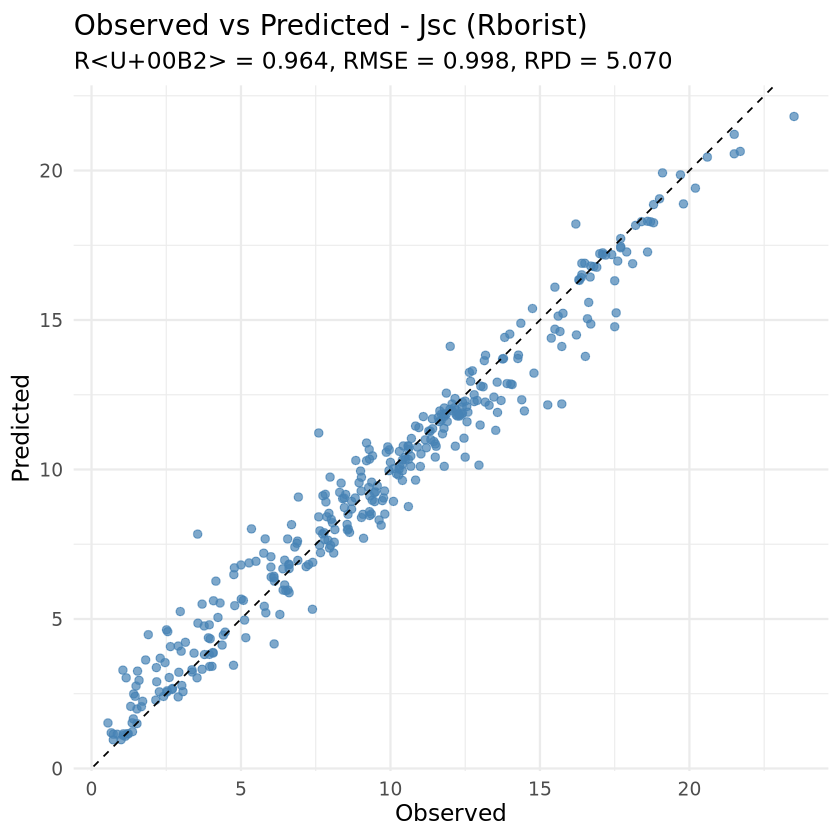

/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv FF Rborist : R<U+00B2> = 0.862, RMSE = 0.043, MAE = 0.032, RPD = 2.591

Training model for: PCEmax 


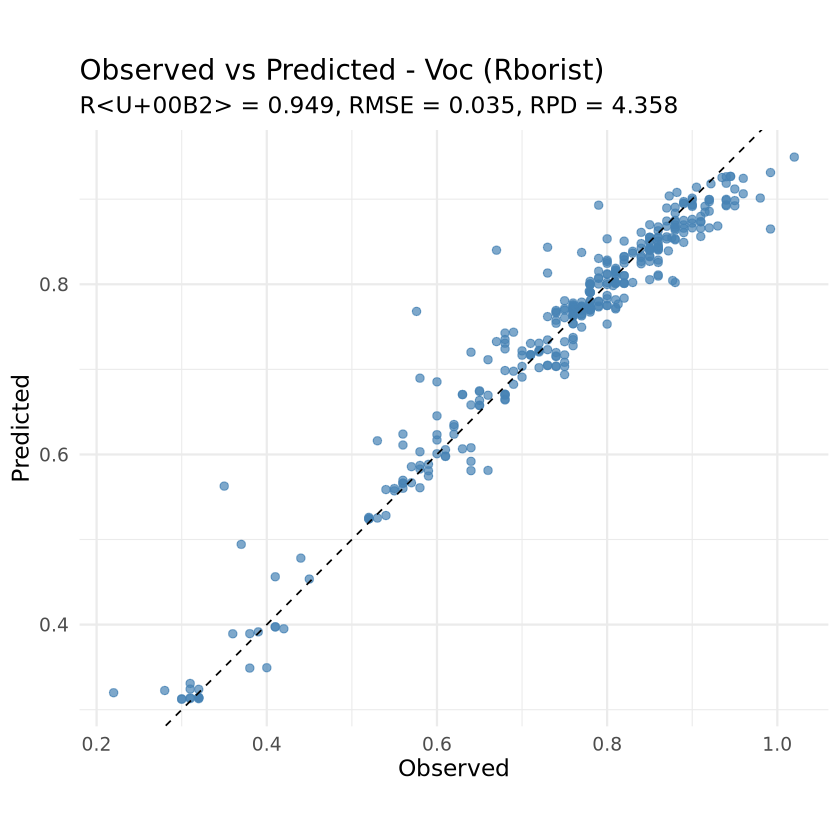

/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv PCEmax Rborist : R<U+00B2> = 0.961, RMSE = 0.549, MAE = 0.400, RPD = 4.811


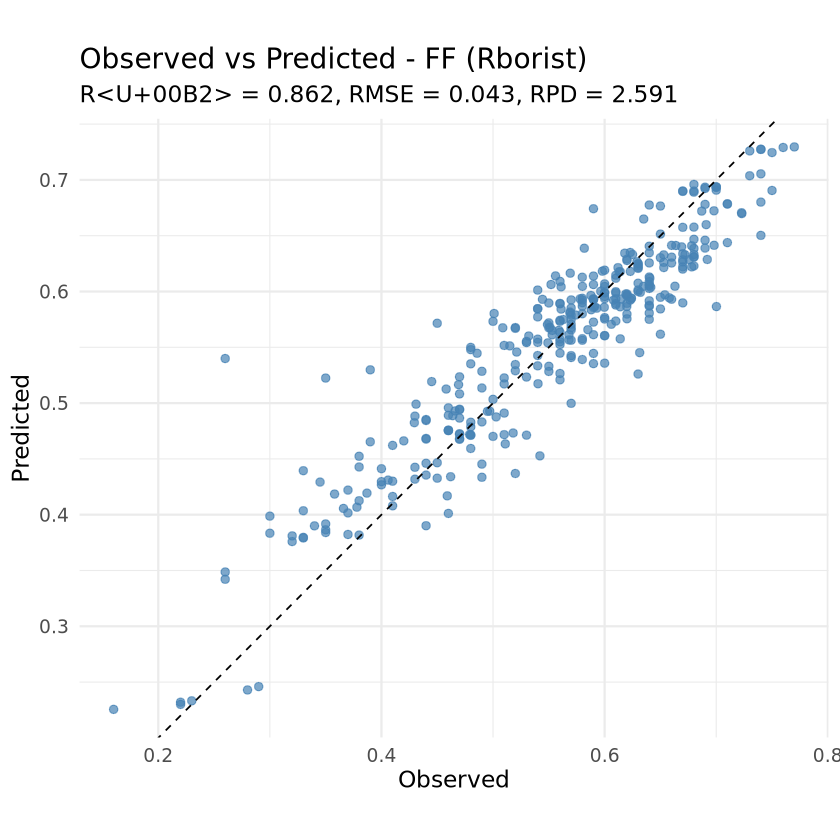

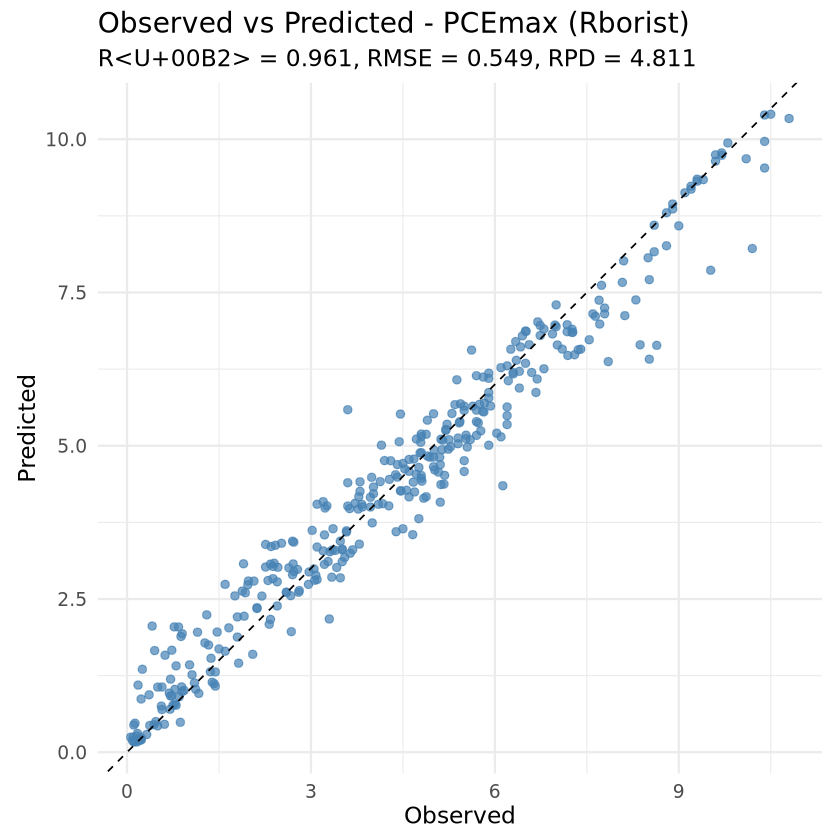

In [2]:
# --- 必要パッケージの読み込み ---
library(caret)
library(ggplot2)
library(Rborist)
library(Metrics)

# --- データの読み込み ---
data_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv"
df_all <- read.csv(data_path)
cat("Processing:", data_path, "\n")

# --- データの整形 ---
target_vars <- c("Jsc", "Voc", "FF", "PCEmax")
feature_vars <- setdiff(colnames(df_all), target_vars)
df_all <- na.omit(df_all)
cat("Final dataset size:", dim(df_all)[1], dim(df_all)[2], "\n")

# --- 結果のプロット保存用リスト ---
plot_list <- list()

# --- モデル学習・評価・図示処理 ---
for (target_var in target_vars) {
  cat("\nTraining model for:", target_var, "\n")

  df <- df_all[, c(feature_vars, target_var)]
  colnames(df)[ncol(df)] <- "Y"  # 目的変数名をYに統一

  set.seed(123)
  ctrl <- trainControl(method = "cv", number = 10)

  model <- train(
    Y ~ .,
    data = df,
    method = "Rborist",
    trControl = ctrl,
    metric = "RMSE",
    preProcess = c("center", "scale"),
    importance = TRUE
  )

  # --- 予測と指標計算 ---
  predictions <- predict(model, df)
  obs <- df$Y

  r2 <- R2(predictions, obs)
  rmse <- RMSE(predictions, obs)
  mae <- MAE(predictions, obs)
  rpd <- sd(obs) / rmse

  cat(sprintf("%s %s Rborist : R² = %.3f, RMSE = %.3f, MAE = %.3f, RPD = %.3f\n",
              data_path, target_var, r2, rmse, mae, rpd))

  # --- 散布図の作成 ---
  p <- ggplot(data.frame(Observed = obs, Predicted = predictions), aes(x = Observed, y = Predicted)) +
    geom_point(color = "steelblue", size = 2, alpha = 0.7) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
    coord_fixed() +
    labs(
      title = paste("Observed vs Predicted -", target_var, "(Rborist)"),
      subtitle = sprintf("R² = %.3f, RMSE = %.3f, RPD = %.3f", r2, rmse, rpd),
      x = "Observed", y = "Predicted"
    ) +
    theme_minimal(base_size = 14)

  print(p)  # Jupyterなどで都度描画したい場合はこちら
  # plot_list[[target_var]] <- p  # まとめて出力したい場合はこの行を使って後で gridExtra::grid.arrange 等に渡す
}
